#### ML Fundamentals Day_55
- Unsupervised ML
   - Anomaly Detection Using Isolation Forest
   - Anomaly Detection Using LOF(Local Outlier Factor)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("thyroid_dataset.csv")

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
df.shape

(6916, 22)

In [5]:
df.isnull().sum()

Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3_measured                  0
TT4_measured                 0
T4U_measured                 0
FTI_measured                 0
Outlier_label                0
dtype: int64

In [6]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

In [7]:
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [8]:
y.head()

0    o
1    o
2    o
3    o
4    o
Name: Outlier_label, dtype: object

In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

In [10]:
x_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [11]:
from sklearn.ensemble import IsolationForest
clf = IsolationForest(
     n_estimators=200,
     contamination=0.036,
     random_state=42
)

In [12]:
labels = clf.fit_predict(x_scaled)

In [13]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [14]:
## Visualise
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

Text(0, 0.5, 'PC2')

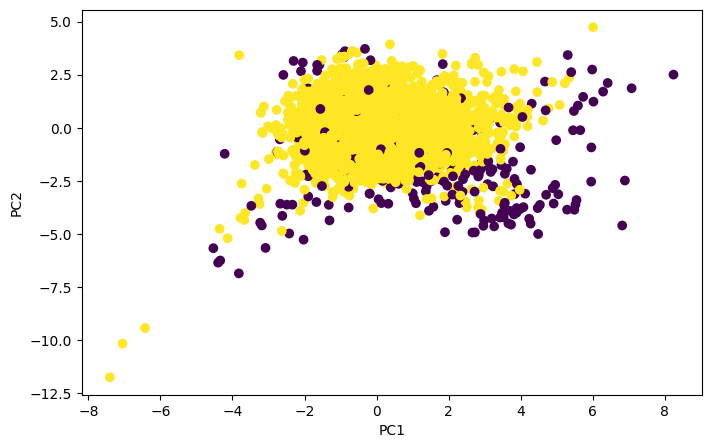

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [16]:
import numpy as np
n_outliers = np.sum(labels==-1)
n_normal = np.sum(labels==1)

print(f"outlier:{n_outliers}")
print(f"normal points:{n_normal}")

outlier:249
normal points:6667


- Local Factor Outlier(LOF)

In [17]:
from sklearn.neighbors import LocalOutlierFactor
neighbs = LocalOutlierFactor(contamination=0.036)
labels = neighbs.fit_predict(x_scaled)

Text(0, 0.5, 'PC2')

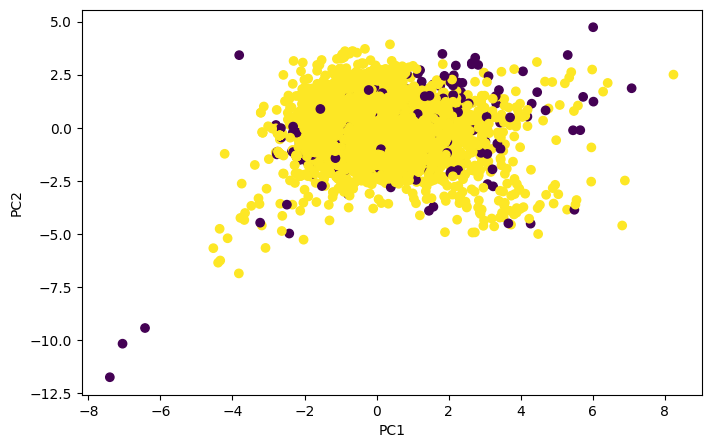

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [19]:
import numpy as np
n_outliers = np.sum(labels==-1)
n_normal = np.sum(labels==1)

print(f"outlier:{n_outliers}")
print(f"normal points:{n_normal}")

outlier:249
normal points:6667
